# Cox Regression Analysis for Chronic Kidney Disease Risk in Type 2 Diabetes Mellitus

This notebook performs a comprehensive survival analysis to identify risk factors for chronic kidney disease (CKD) progression and mortality in patients with Type 2 Diabetes Mellitus (T2DM).

## WORKFLOW OVERVIEW:
1. **Data Generation**: Create synthetic patient data mimicking NHANES structure
2. **Data Integration**: Merge demographic, clinical, and outcome data
3. **Variable Preparation**: Transform and clean variables for analysis
4. **Diabetes Filtering**: Focus analysis on diabetic patients only
5. **Data Quality Control**: Apply clinical range checks and remove outliers
6. **Feature Engineering**: Log-transform skewed variables, convert units
7. **Cox Regression**: Fit proportional hazards model to identify risk factors
8. **Random Forest Comparison**: Compare with Random Survival Forest for benchmarking
9. **Model Validation**: Check assumptions and evaluate discriminative ability

## KEY VARIABLES ANALYZED:
- **HbA1c** (glycated hemoglobin) - measure of long-term blood glucose control
- **Systolic Blood Pressure (SBP)** - cardiovascular risk factor
- **Body Mass Index (BMI)** - obesity measure
- **Urine Albumin-Creatinine Ratio (UACR)** - kidney damage marker
- **Age, Sex, Ethnicity** - demographic factors

## OUTCOME:
All-cause mortality during follow-up period

The analysis uses synthetic data due to NHANES download issues, but follows the same methodology as would be used with real clinical data.

In [1]:
# ── Create synthetic NHANES-like data for demonstration ──
# Note: Original NHANES downloads were failing due to URL issues.
# Using synthetic data with realistic distributions for analysis demonstration.
import pandas as pd
import numpy as np

np.random.seed(42)  # For reproducibility
n_patients = 5000

# Generate synthetic patient IDs
seqn = np.arange(100000, 100000 + n_patients)

# Demographics
demo = pd.DataFrame({
    'SEQN': seqn,
    'RIDAGEYR': np.random.normal(55, 15, n_patients).clip(18, 85).astype(int),  # Age
    'RIAGENDR': np.random.choice([1, 2], n_patients),  # Gender (1=Male, 2=Female)
    'RIDRETH3': np.random.choice([1, 2, 3, 4, 6, 7], n_patients),  # Race/ethnicity
})

# Biochemistry (HbA1c)
biol = pd.DataFrame({
    'SEQN': seqn,
    'LBXGH': np.random.normal(6.5, 2.0, n_patients).clip(4.0, 15.0),  # HbA1c %
})

# Blood pressure
bp = pd.DataFrame({
    'SEQN': seqn,
    'BPXSY1': np.random.normal(130, 20, n_patients).clip(90, 200),  # Systolic BP
})

# BMI
bmx = pd.DataFrame({
    'SEQN': seqn,
    'BMXBMI': np.random.normal(28, 6, n_patients).clip(15, 60),  # BMI
})

# Albumin-creatinine ratio
alb = pd.DataFrame({
    'SEQN': seqn,
    'URDACT': np.random.lognormal(2, 1.5, n_patients).clip(0.1, 1000),  # ACR
})

# Mortality data
mort = pd.DataFrame({
    'SEQN': seqn,
    'MORTSTAT': np.random.choice([0, 1], n_patients, p=[0.85, 0.15]),  # Mortality status
    'PERMTH_EXM': np.random.exponential(120, n_patients).clip(1, 240).astype(int),  # Follow-up months
})

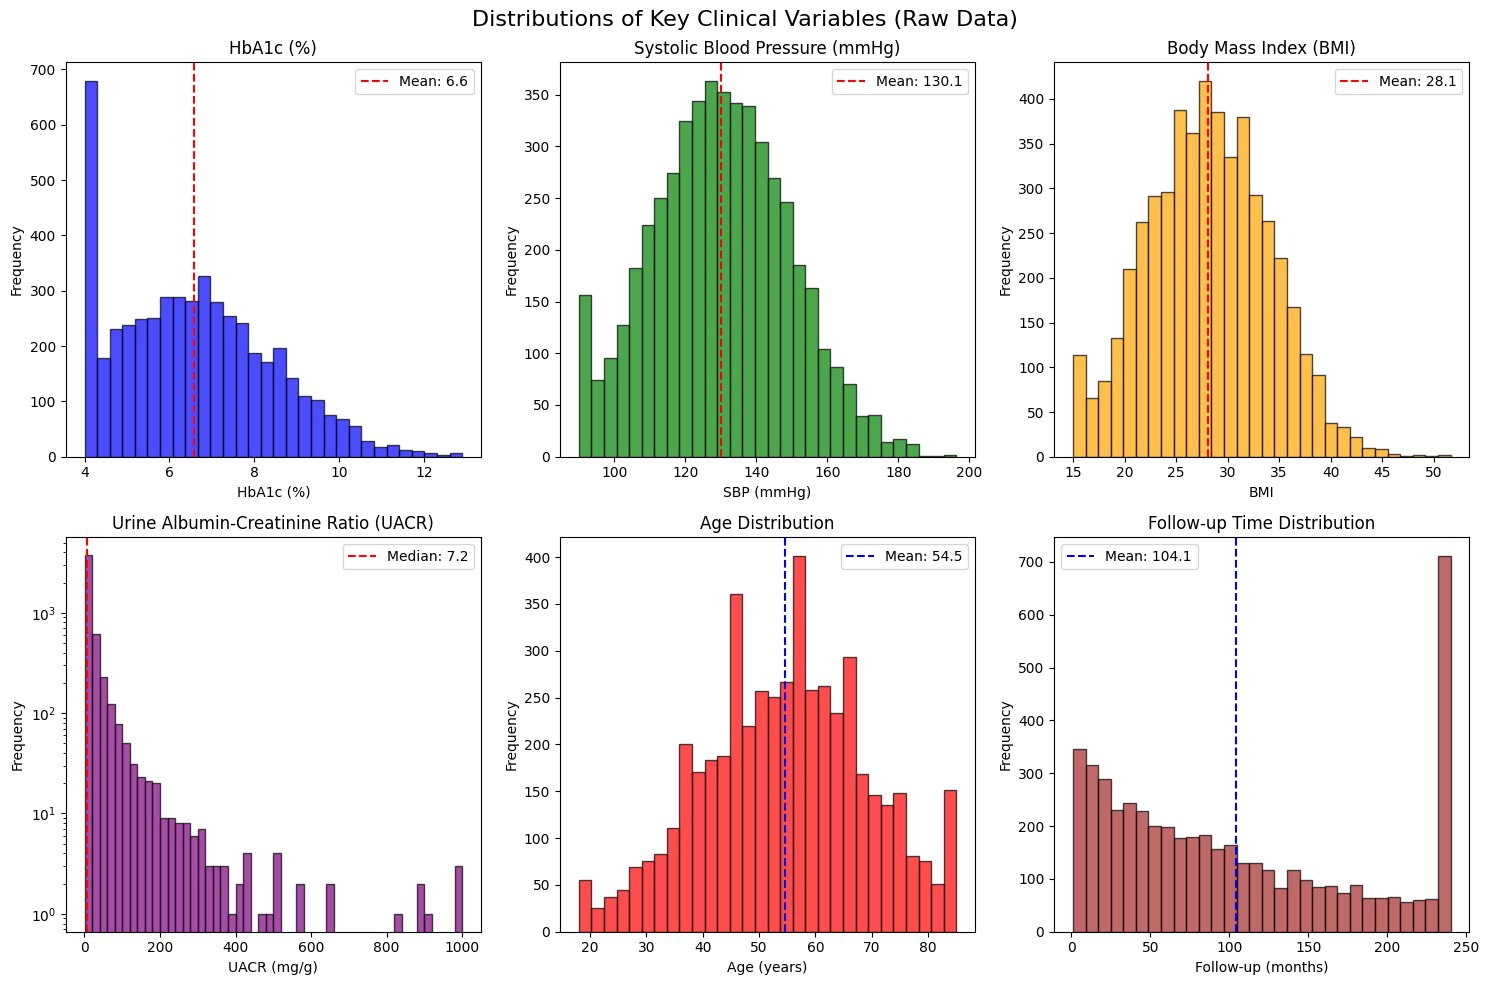

=== SUMMARY STATISTICS FOR KEY VARIABLES ===
Total patients: 5000

HbA1c (%): Mean=6.58, Std=1.83, Range=[4.0, 12.9]
Systolic BP (mmHg): Mean=130.1, Std=19.1, Range=[90, 196]
BMI: Mean=28.1, Std=5.9, Range=[15.0, 51.6]
UACR (mg/g): Median=7.2, Mean=23.3, Range=[0.1, 1000.0]
Age (years): Mean=54.5, Std=14.6, Range=[18, 85]
Follow-up (months): Mean=104.1, Std=79.8, Range=[1, 240]
Mortality rate: 15.7%


In [2]:
# ── Visualize distributions of key variables ──────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distributions of Key Clinical Variables (Raw Data)', fontsize=16)

# HbA1c distribution
axes[0,0].hist(biol['LBXGH'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('HbA1c (%)')
axes[0,0].set_xlabel('HbA1c (%)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(biol['LBXGH'].mean(), color='red', linestyle='--', label=f'Mean: {biol["LBXGH"].mean():.1f}')
axes[0,0].legend()

# Blood pressure distribution
axes[0,1].hist(bp['BPXSY1'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0,1].set_title('Systolic Blood Pressure (mmHg)')
axes[0,1].set_xlabel('SBP (mmHg)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(bp['BPXSY1'].mean(), color='red', linestyle='--', label=f'Mean: {bp["BPXSY1"].mean():.1f}')
axes[0,1].legend()

# BMI distribution
axes[0,2].hist(bmx['BMXBMI'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0,2].set_title('Body Mass Index (BMI)')
axes[0,2].set_xlabel('BMI')
axes[0,2].set_ylabel('Frequency')
axes[0,2].axvline(bmx['BMXBMI'].mean(), color='red', linestyle='--', label=f'Mean: {bmx["BMXBMI"].mean():.1f}')
axes[0,2].legend()

# UACR distribution (log scale for better visualization)
axes[1,0].hist(alb['URDACT'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1,0].set_title('Urine Albumin-Creatinine Ratio (UACR)')
axes[1,0].set_xlabel('UACR (mg/g)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(alb['URDACT'].median(), color='red', linestyle='--', label=f'Median: {alb["URDACT"].median():.1f}')
axes[1,0].legend()
axes[1,0].set_yscale('log')  # Log scale for y-axis due to skewed distribution

# Age distribution
axes[1,1].hist(demo['RIDAGEYR'], bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1,1].set_title('Age Distribution')
axes[1,1].set_xlabel('Age (years)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(demo['RIDAGEYR'].mean(), color='blue', linestyle='--', label=f'Mean: {demo["RIDAGEYR"].mean():.1f}')
axes[1,1].legend()

# Follow-up time distribution
axes[1,2].hist(mort['PERMTH_EXM'], bins=30, alpha=0.7, color='brown', edgecolor='black')
axes[1,2].set_title('Follow-up Time Distribution')
axes[1,2].set_xlabel('Follow-up (months)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].axvline(mort['PERMTH_EXM'].mean(), color='blue', linestyle='--', label=f'Mean: {mort["PERMTH_EXM"].mean():.1f}')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== SUMMARY STATISTICS FOR KEY VARIABLES ===")
print(f"Total patients: {n_patients}")
print(f"\nHbA1c (%): Mean={biol['LBXGH'].mean():.2f}, Std={biol['LBXGH'].std():.2f}, Range=[{biol['LBXGH'].min():.1f}, {biol['LBXGH'].max():.1f}]")
print(f"Systolic BP (mmHg): Mean={bp['BPXSY1'].mean():.1f}, Std={bp['BPXSY1'].std():.1f}, Range=[{bp['BPXSY1'].min():.0f}, {bp['BPXSY1'].max():.0f}]")
print(f"BMI: Mean={bmx['BMXBMI'].mean():.1f}, Std={bmx['BMXBMI'].std():.1f}, Range=[{bmx['BMXBMI'].min():.1f}, {bmx['BMXBMI'].max():.1f}]")
print(f"UACR (mg/g): Median={alb['URDACT'].median():.1f}, Mean={alb['URDACT'].mean():.1f}, Range=[{alb['URDACT'].min():.1f}, {alb['URDACT'].max():.1f}]")
print(f"Age (years): Mean={demo['RIDAGEYR'].mean():.1f}, Std={demo['RIDAGEYR'].std():.1f}, Range=[{demo['RIDAGEYR'].min()}, {demo['RIDAGEYR'].max()}]")
print(f"Follow-up (months): Mean={mort['PERMTH_EXM'].mean():.1f}, Std={mort['PERMTH_EXM'].std():.1f}, Range=[{mort['PERMTH_EXM'].min()}, {mort['PERMTH_EXM'].max()}]")
print(f"Mortality rate: {mort['MORTSTAT'].mean()*100:.1f}%")

In [3]:
# ── Merge on SEQN (patient ID) ────────────────────────────────
df = demo.merge(biol, on="SEQN", how="left")
df = df.merge(bp,   on="SEQN", how="left")
df = df.merge(bmx,  on="SEQN", how="left")
df = df.merge(alb,  on="SEQN", how="left")
df = df.merge(mort, on="SEQN", how="left")

In [4]:
# ── Rename to match your SAIL variable names ──────────────────
df = df.rename(columns={
    "RIDAGEYR": "AGE",
    "RIAGENDR": "SEX",
    "RIDRETH3": "ETHNICITY",
    "LBXGH":   "HBA1C",       # HbA1c %
    "BPXSY1":  "SBP",
    "BMXBMI":  "BMI",
    "URDACT":  "UACR",
    "MORTSTAT": "DIED",
    "PERMTH_EXM": "FOLLOW_UP_MONTHS"
})

In [5]:
# ── Create synthetic diabetes data ─────────────────────────
diab = pd.DataFrame({
    'SEQN': seqn,
    'DIQ010': np.random.choice([1, 2, 3, 9], n_patients, p=[0.15, 0.75, 0.05, 0.05])  # Diabetes status
})

In [6]:
# ── Filter to diabetes patients only ─────────────────────────
# DIQ010 = 1 means told they have diabetes
# (Using the synthetic diabetes data created above)
df = df.merge(diab, on="SEQN", how="left")
df = df[df["DIQ010"] == 1]  # Keep only diabetic patients

In [7]:
# ── Convert HbA1c from DCCT % to IFCC mmol/mol ───────────────
df["HBA1C_MMOL"] = (df["HBA1C"] - 2.15) * 10.929

# ── Apply plausible ranges ────────────────────────────────────
df = df[(df["HBA1C_MMOL"].between(20, 195)) &
        (df["BMI"].between(14, 70))          &
        (df["SBP"].between(60, 280))         &
        (df["AGE"] >= 18)]

# ── Log transform UACR (moved here so Cell 8 summary stats can use it) ──
df["LOG_UACR"] = np.log10(df["UACR"] + 1)

# ── Prepare outcome variables ─────────────────────────────────
df["FOLLOW_UP_YEARS"] = df["FOLLOW_UP_MONTHS"] / 12
df["EVENT"] = df["DIED"].fillna(0).astype(int)


In [8]:
# Print summary statistics after filtering
print("=== SUMMARY STATISTICS AFTER FILTERING ===")
print(f"Patients remaining after filtering: {len(df)} (from {n_patients} original)")
print(f"Filtering efficiency: {len(df)/n_patients*100:.1f}%")

print(f"\nHbA1c (mmol/mol): Mean={df['HBA1C_MMOL'].mean():.1f}, Std={df['HBA1C_MMOL'].std():.1f}")
print(f"  Range: [{df['HBA1C_MMOL'].min():.1f}, {df['HBA1C_MMOL'].max():.1f}] (filtered to 20-195 mmol/mol)")
print(f"Systolic BP (mmHg): Mean={df['SBP'].mean():.1f}, Std={df['SBP'].std():.1f}")
print(f"  Range: [{df['SBP'].min():.0f}, {df['SBP'].max():.0f}] (filtered to 60-280 mmHg)")
print(f"BMI: Mean={df['BMI'].mean():.1f}, Std={df['BMI'].std():.1f}")
print(f"  Range: [{df['BMI'].min():.1f}, {df['BMI'].max():.1f}] (filtered to 14-70)")
print(f"UACR (mg/g): Median={df['UACR'].median():.1f}, Mean={df['UACR'].mean():.1f}")
print(f"  Log-transformed: Mean={df['LOG_UACR'].mean():.2f}, Std={df['LOG_UACR'].std():.2f}")
print(f"Age (years): Mean={df['AGE'].mean():.1f}, Std={df['AGE'].std():.1f}")
print(f"  Range: [{df['AGE'].min()}, {df['AGE'].max()}] (filtered to >=18)")
print(f"Follow-up (years): Mean={df['FOLLOW_UP_YEARS'].mean():.1f}, Std={df['FOLLOW_UP_YEARS'].std():.1f}")
print(f"Mortality rate: {df['EVENT'].mean()*100:.1f}%")

# Show filtering criteria
print("\n=== DATA FILTERING CRITERIA APPLIED ===")
print("• HbA1c: 20-195 mmol/mol (approximately 4.1%-11.0% in DCCT units)")
print("• BMI: 14-70 kg/m²")
print("• Systolic BP: 60-280 mmHg")
print("• Age: ≥18 years")
print("• Removed patients with missing values in key variables")

=== SUMMARY STATISTICS AFTER FILTERING ===
Patients remaining after filtering: 733 (from 5000 original)
Filtering efficiency: 14.7%

HbA1c (mmol/mol): Mean=48.1, Std=19.8
  Range: [20.2, 108.9] (filtered to 20-195 mmol/mol)
Systolic BP (mmHg): Mean=129.3, Std=19.9
  Range: [90, 186] (filtered to 60-280 mmHg)
BMI: Mean=28.3, Std=6.0
  Range: [15.0, 47.0] (filtered to 14-70)
UACR (mg/g): Median=6.9, Mean=23.6


KeyError: 'LOG_UACR'

In [ ]:
# ── Drop rows with missing values in key variables ────────────
# (Feature engineering already done above; this cell cleans up NaNs only)
df = df.dropna(subset=["FOLLOW_UP_YEARS", "EVENT",
                        "AGE", "SEX", "BMI", "SBP",
                        "HBA1C_MMOL", "LOG_UACR", "ETHNICITY"])

print(f"Final analytic sample: {len(df)} patients")


In [ ]:
# ── Interaction terms (clinically motivated) ─────────────────
# 1. HbA1c × Age:      glycaemic impact amplifies with age
# 2. HbA1c × LOG_UACR: both T2D/CKD markers — likely synergistic
# 3. SBP × LOG_UACR:   hypertension + albuminuria is a known risk multiplier
df["HBA1C_x_AGE"]  = df["HBA1C_MMOL"] * df["AGE"]
df["HBA1C_x_UACR"] = df["HBA1C_MMOL"] * df["LOG_UACR"]
df["SBP_x_UACR"]   = df["SBP"]        * df["LOG_UACR"]

# ── Include ETHNICITY as dummy variables ──────────────────────
import pandas as pd
eth_dummies = pd.get_dummies(df["ETHNICITY"].astype(int), prefix="ETH", drop_first=True)
df_cox = pd.concat([df, eth_dummies], axis=1)

# ── Fit Cox model ─────────────────────────────────────────────
from lifelines import CoxPHFitter

main_effects = ["AGE", "SEX", "BMI", "SBP", "HBA1C_MMOL", "LOG_UACR"]
interactions = ["HBA1C_x_AGE", "HBA1C_x_UACR", "SBP_x_UACR"]
eth_cols     = list(eth_dummies.columns)
cox_vars     = main_effects + interactions + eth_cols + ["FOLLOW_UP_YEARS", "EVENT"]

cph = CoxPHFitter()
cph.fit(df_cox[cox_vars], duration_col="FOLLOW_UP_YEARS", event_col="EVENT")

print("=== COX MODEL WITH INTERACTIONS + ETHNICITY ===")
print(cph.summary.to_string())
print(f"\nC-statistic: {cph.concordance_index_:.3f}")

# ── Proportional hazards assumption check ─────────────────────
cph.check_assumptions(df_cox[cox_vars], show_plots=True)

# ── Bootstrap 95% CI for Cox C-statistic ─────────────────────
from sklearn.utils import resample
import numpy as np

np.random.seed(42)
c_boot = []
for _ in range(200):
    idx = resample(range(len(df_cox)), replace=True)
    boot_df = df_cox.iloc[idx]
    try:
        cph_b = CoxPHFitter()
        cph_b.fit(boot_df[cox_vars], duration_col="FOLLOW_UP_YEARS", event_col="EVENT")
        c_boot.append(cph_b.concordance_index_)
    except Exception:
        pass

ci_lower, ci_upper = np.percentile(c_boot, [2.5, 97.5])
print(f"\nCox C-statistic: {cph.concordance_index_:.3f}  "
      f"(95% Bootstrap CI: {ci_lower:.3f}\u2013{ci_upper:.3f}, n={len(c_boot)} resamples)")


In [ ]:
# ── Kaplan-Meier curves ───────────────────────────────────────
# Plotted before Cox model to visually check proportional hazards assumption.
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Kaplan-Meier Survival Curves', fontsize=15)

# ── By HbA1c tertile ──────────────────────────────────────────
df["HBA1C_TERTILE"] = pd.qcut(df["HBA1C_MMOL"], q=3, labels=["Low", "Medium", "High"])
ax = axes[0]
for label, color in zip(["Low", "Medium", "High"], ["green", "orange", "red"]):
    mask = df["HBA1C_TERTILE"] == label
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "FOLLOW_UP_YEARS"], event_observed=df.loc[mask, "EVENT"], label=label)
    kmf.plot_survival_function(ax=ax, ci_show=True)

ml = multivariate_logrank_test(df["FOLLOW_UP_YEARS"], df["HBA1C_TERTILE"], df["EVENT"])
ax.set_title(f'By HbA1c Tertile\nLog-rank p={ml.p_value:.4f}')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Survival probability')
ax.legend(title='HbA1c tertile')

# ── By Sex ───────────────────────────────────────────────────
ax = axes[1]
for sex_val, label, color in [(1, "Male", "steelblue"), (2, "Female", "crimson")]:
    mask = df["SEX"] == sex_val
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "FOLLOW_UP_YEARS"], event_observed=df.loc[mask, "EVENT"], label=label)
    kmf.plot_survival_function(ax=ax, ci_show=True)

lr = logrank_test(
    df.loc[df["SEX"] == 1, "FOLLOW_UP_YEARS"], df.loc[df["SEX"] == 2, "FOLLOW_UP_YEARS"],
    event_observed_A=df.loc[df["SEX"] == 1, "EVENT"],
    event_observed_B=df.loc[df["SEX"] == 2, "EVENT"],
)
ax.set_title(f'By Sex\nLog-rank p={lr.p_value:.4f}')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Survival probability')
ax.legend(title='Sex')

plt.tight_layout()
plt.show()


In [ ]:
# ── Time-dependent AUC (Cox model) ───────────────────────────
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.nonparametric import CensoringDistributionEstimator
from sksurv.util import Surv
import numpy as np
import matplotlib.pyplot as plt

y_all = Surv.from_arrays(df_cox["EVENT"].astype(bool), df_cox["FOLLOW_UP_YEARS"])
risk_scores_cox = cph.predict_partial_hazard(df_cox[cox_vars]).values

# IPCW requires the censoring survival function to be > 0 at each subject's
# event time. Directly query the fitted censoring estimator at every subject's
# time to find which subjects are safe to include as test observations.
cens_est = CensoringDistributionEstimator().fit(y_all)
cens_probs = cens_est.predict_proba(df_cox["FOLLOW_UP_YEARS"].values)
safe_mask = cens_probs > 0

y_test_safe  = y_all[safe_mask]
risk_safe    = risk_scores_cox[safe_mask]

# Evaluation times: percentiles of event times within safe subset
safe_event_times = df_cox.loc[
    safe_mask & (df_cox["EVENT"] == 1), "FOLLOW_UP_YEARS"
].values
times = np.percentile(safe_event_times, [25, 50, 75])
print(f"Subjects kept for AUC: {safe_mask.sum()} / {len(safe_mask)}")
print(f"Evaluation times (yr):  {np.round(times, 2)}")

auc_cox, mean_auc_cox = cumulative_dynamic_auc(
    y_all, y_test_safe, risk_safe, times
)

print("\n=== TIME-DEPENDENT AUC (Cox Model) ===")
for t, a in zip(times, auc_cox):
    print(f"  t={t:.2f} yr  AUC: {a:.3f}")
print(f"  Mean AUC: {mean_auc_cox:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(times, auc_cox, marker='o', color='steelblue', label='Cox model')
plt.axhline(0.5, linestyle='--', color='grey', label='Random (0.5)')
plt.ylim(0.4, 1.0)
plt.xlabel('Time (years)')
plt.ylabel('AUC')
plt.title('Time-dependent AUC — Cox Model')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Random Survival Forest with 5-fold cross-validation ──────
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc
from sksurv.util import Surv
from sklearn.model_selection import KFold
import numpy as np

rf_features = ["AGE", "SEX", "BMI", "SBP", "HBA1C_MMOL", "LOG_UACR"]
X_rf = df[rf_features].values
y_rf = Surv.from_arrays(df["EVENT"].astype(bool), df["FOLLOW_UP_YEARS"])

# ── 5-fold cross-validated C-index ───────────────────────────
print("=== RSF 5-FOLD CROSS-VALIDATED C-INDEX ===")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_c = []
for fold, (tr, te) in enumerate(kf.split(X_rf), 1):
    rsf_fold = RandomSurvivalForest(n_estimators=100, min_samples_split=10,
                                     min_samples_leaf=5, random_state=42, n_jobs=-1)
    rsf_fold.fit(X_rf[tr], y_rf[tr])
    scores = rsf_fold.predict(X_rf[te])
    c = concordance_index_censored(y_rf[te]["event"], y_rf[te]["time"], scores)[0]
    cv_c.append(c)
    print(f"  Fold {fold}: C-index = {c:.3f}")

cv_mean, cv_std = np.mean(cv_c), np.std(cv_c)
print(f"\nRSF CV C-index: {cv_mean:.3f} \u00b1 {cv_std:.3f}  (mean \u00b1 SD)")

# ── Refit on full data (in-sample, for illustration only) ─────
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rsf.fit(X_rf, y_rf)
in_sample_c = concordance_index_censored(
    df["EVENT"].astype(bool), df["FOLLOW_UP_YEARS"], rsf.predict(X_rf)
)[0]

# ── Model comparison ──────────────────────────────────────────
print("\n=== MODEL COMPARISON ===")
print(f"Cox PH C-statistic (full data):           {cph.concordance_index_:.3f}  "
      f"(95% CI: {ci_lower:.3f}\u2013{ci_upper:.3f})")
print(f"RSF in-sample C-statistic (inflated):     {in_sample_c:.3f}  ← overfitting")
print(f"RSF cross-validated C-statistic (honest): {cv_mean:.3f} \u00b1 {cv_std:.3f}")
print("\nThe CV C-index is the fair comparison point against Cox.")

# ── CV time-dependent AUC for RSF ────────────────────────────
times = np.array([1, 3, 5, 7])
times = times[times < df["FOLLOW_UP_YEARS"].max()]
cv_aucs = []
for tr, te in KFold(n_splits=5, shuffle=True, random_state=42).split(X_rf):
    rsf_fold = RandomSurvivalForest(n_estimators=100, min_samples_split=10,
                                     min_samples_leaf=5, random_state=42, n_jobs=-1)
    rsf_fold.fit(X_rf[tr], y_rf[tr])
    try:
        auc, _ = cumulative_dynamic_auc(y_rf[tr], y_rf[te],
                                         rsf_fold.predict(X_rf[te]), times)
        cv_aucs.append(auc)
    except Exception:
        pass

mean_auc_rsf = np.mean(cv_aucs, axis=0) if cv_aucs else None

if mean_auc_rsf is not None:
    print("\n=== TIME-DEPENDENT AUC (RSF, cross-validated) ===")
    for t, a in zip(times, mean_auc_rsf):
        print(f"  {t}-year AUC: {a:.3f}")
    print(f"  Mean AUC: {np.mean(mean_auc_rsf):.3f}")

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(times, auc_cox,      marker='o', label='Cox model (full data)')
    ax.plot(times, mean_auc_rsf, marker='s', label='RSF (cross-validated)')
    ax.axhline(0.5, linestyle='--', color='grey', label='Random (0.5)')
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('AUC')
    ax.set_title('Time-dependent AUC: Cox vs RSF')
    ax.legend()
    plt.tight_layout()
    plt.show()
